In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings 
import joblib
warnings.filterwarnings('ignore')

In [2]:
df =pd.read_csv('../data/Teen_Mental_Health_Dataset.csv')
df.shape

(2500, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   object 
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 234.5+ KB


In [4]:
df.describe().round(4)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,15.9780,4.4580,6.1924,1.7148,2.8909,0.9918,5.5964,5.1648
std,2.0036,2.0169,1.0187,0.7166,0.5596,0.5870,3.0390,3.0025
min,13.0000,1.0000,4.0000,0.5000,2.0000,0.0000,1.0000,1.0000
25%,14.0000,2.7000,5.5000,1.1000,2.4200,0.5000,3.0000,2.0000
50%,16.0000,4.4000,6.2000,1.7000,2.8800,1.0000,6.0000,5.0000
75%,18.0000,6.2000,6.9000,2.3000,3.3400,1.5000,8.0000,8.0000
max,19.0000,8.0000,9.0000,3.0000,4.0000,2.0000,10.0000,10.0000


In [5]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
depression_risk             0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
# finding unique categorical values
for u in df.select_dtypes(exclude='number'):
    print(df[u].value_counts())
    print('-----------')

gender
female    1255
male      1245
Name: count, dtype: int64
-----------
platform_usage
Other        632
Both         628
Instagram    627
TikTok       613
Name: count, dtype: int64
-----------
social_interaction_level
high      849
medium    841
low       810
Name: count, dtype: int64
-----------
depression_risk
low       1266
medium     650
high       584
Name: count, dtype: int64
-----------


In [8]:
numeric_colums=df.select_dtypes(include='number')
categorical_colums=df.select_dtypes(exclude='number')
print(numeric_colums.columns)

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level'],
      dtype='object')


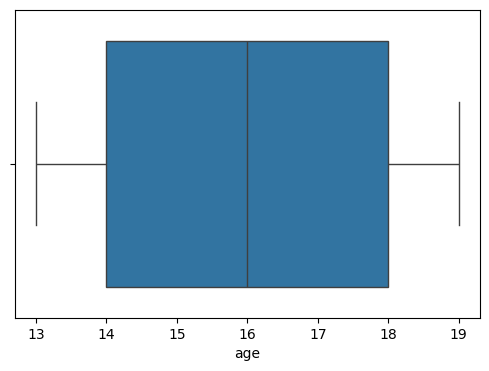

distribution of age


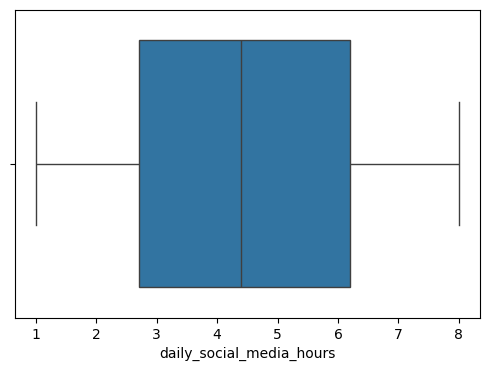

distribution of daily_social_media_hours


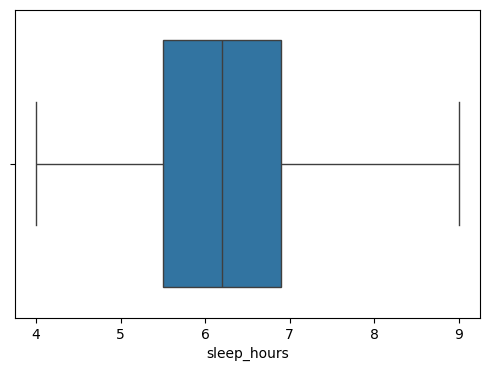

distribution of sleep_hours


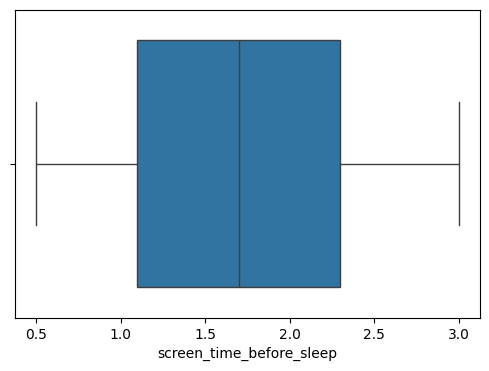

distribution of screen_time_before_sleep


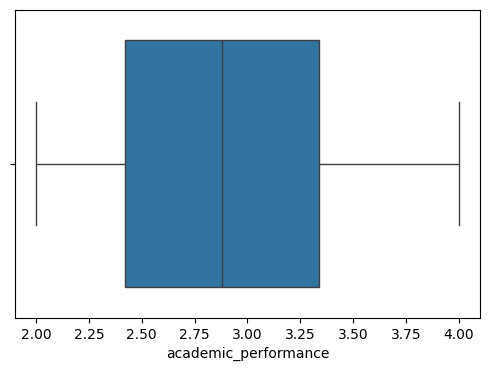

distribution of academic_performance


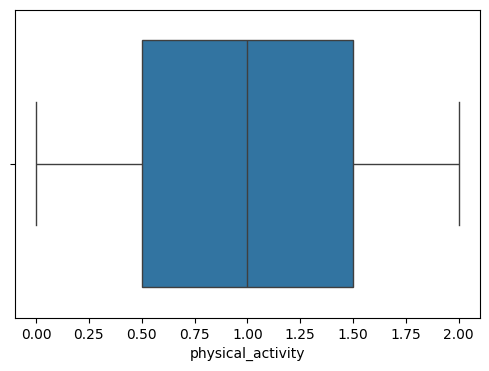

distribution of physical_activity


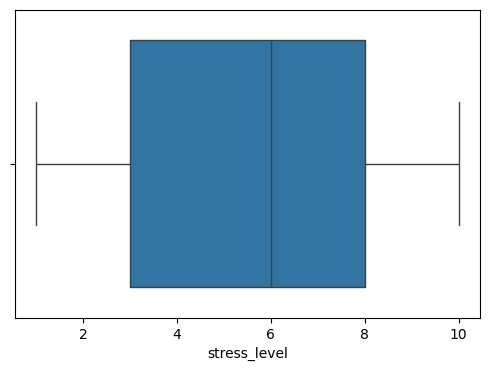

distribution of stress_level


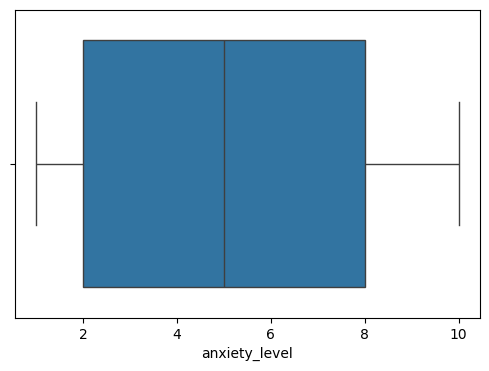

distribution of anxiety_level


In [9]:
for col in numeric_colums:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col,data=df)
    plt.savefig(f'../images/boxplot of {col}.png',bbox_inches='tight',dpi=300)
    plt.show()
    print(f'distribution of {col}')
    plt.close()

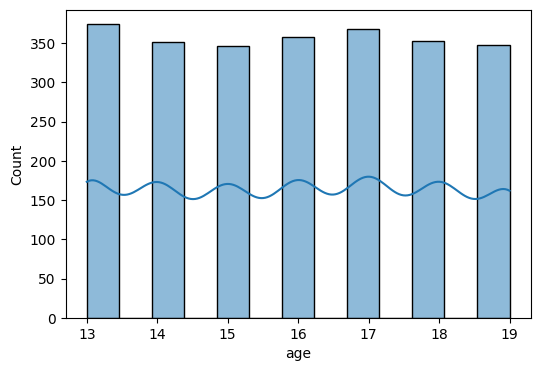

distribution ofage


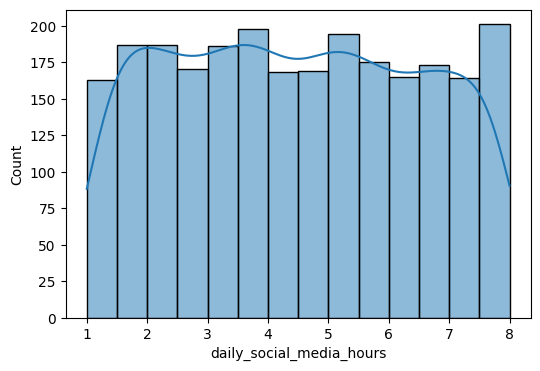

distribution ofdaily_social_media_hours


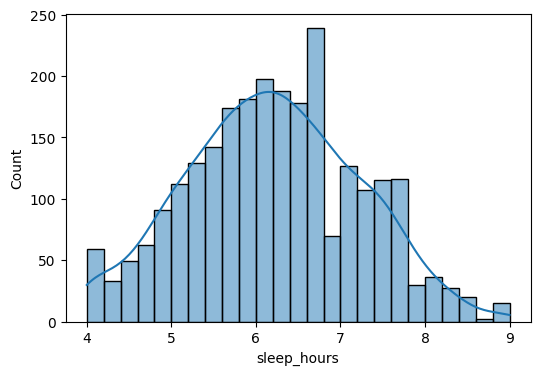

distribution ofsleep_hours


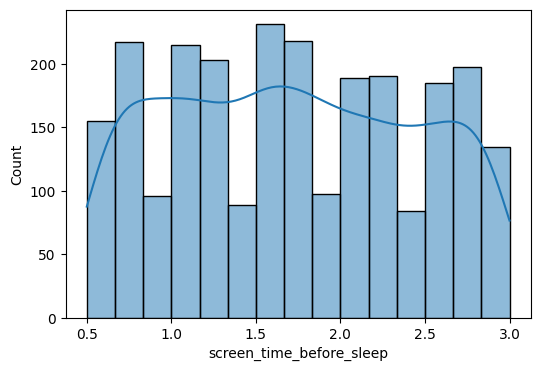

distribution ofscreen_time_before_sleep


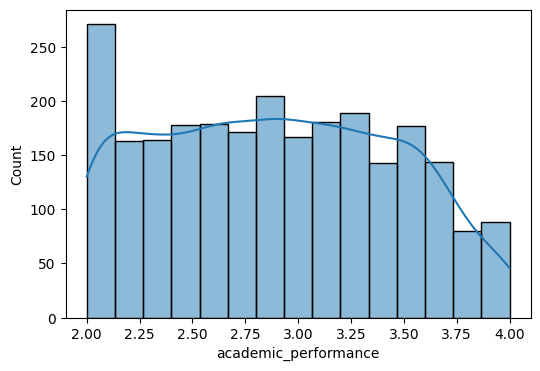

distribution ofacademic_performance


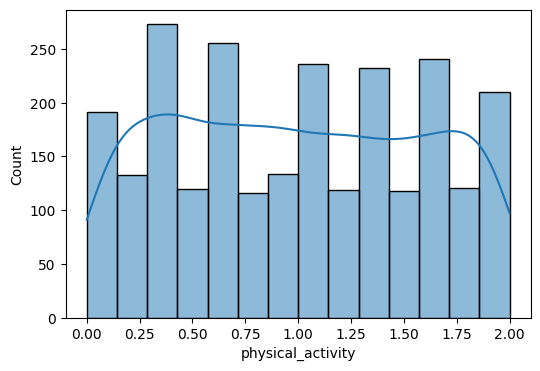

distribution ofphysical_activity


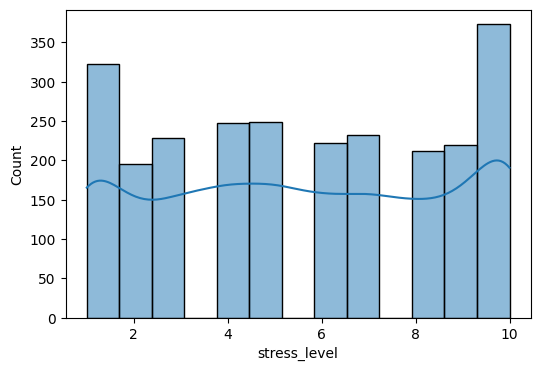

distribution ofstress_level


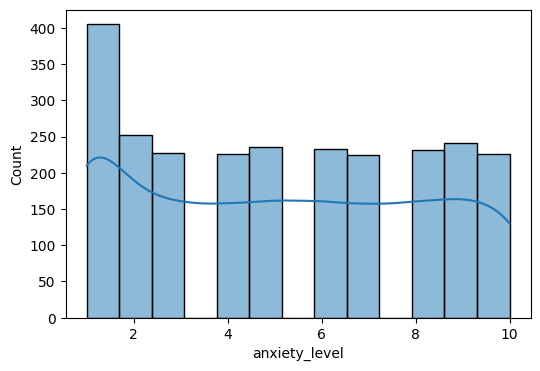

distribution ofanxiety_level


In [10]:
for col in numeric_colums:
    plt.figure(figsize=(6,4))
    sns.histplot(x=col,data=df,kde=True)
    plt.savefig(f'../images/histplot of {col}.png',bbox_inches='tight',dpi=300)
    plt.show()
    print(f'distribution of{col}')
    plt.close()

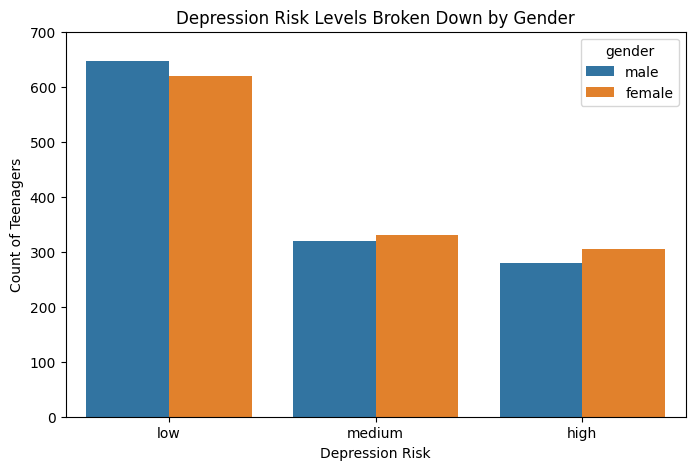

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='depression_risk', hue='gender', order=['low', 'medium', 'high'])
plt.title('Depression Risk Levels Broken Down by Gender')
plt.xlabel('Depression Risk')
plt.ylabel('Count of Teenagers')
plt.ylim(0,700)
plt.savefig('../images/depression_risk_by_gender.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()


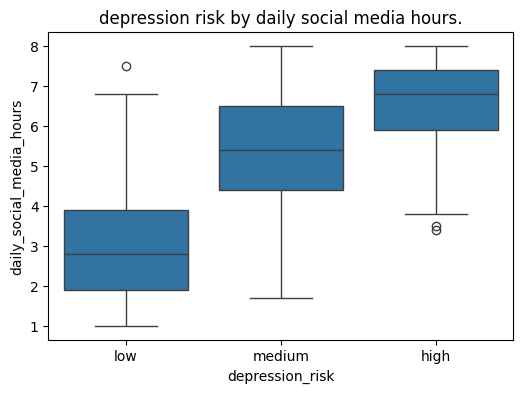

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='depression_risk', y='daily_social_media_hours', data=df , order=['low', 'medium', 'high'])
plt.title('depression risk by daily social media hours.')
plt.savefig('../images/depression_risk_by_daily_social_media_hours.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

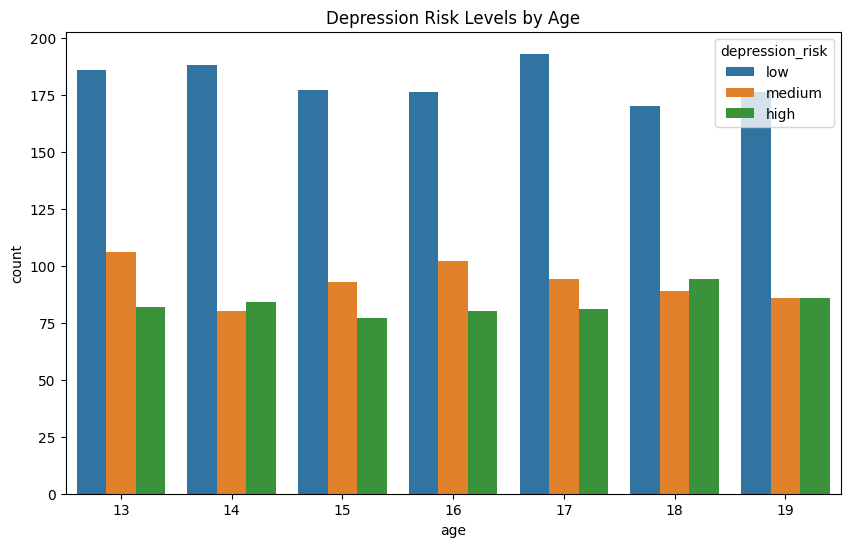

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(x='age', hue='depression_risk', data=df, hue_order=['low', 'medium', 'high'])
plt.title('Depression Risk Levels by Age')
plt.savefig('../images/depression_risk_by_age.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

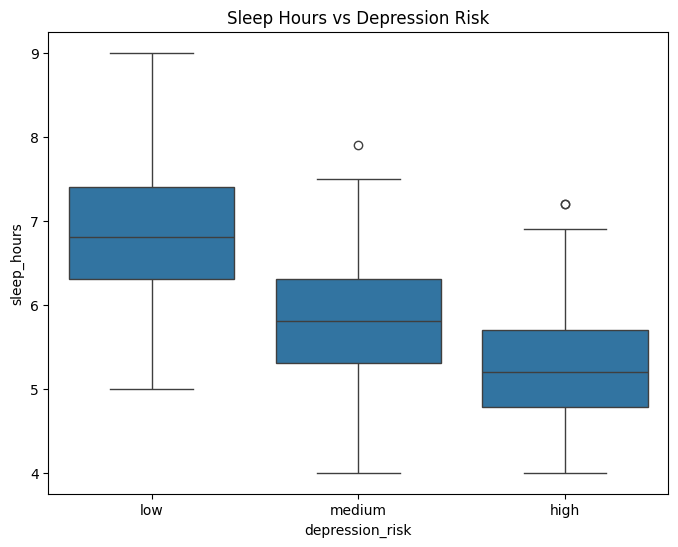

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='depression_risk', y='sleep_hours', data=df, order=['low', 'medium', 'high'])
plt.title('Sleep Hours vs Depression Risk')
plt.savefig('../images/sleep_hours_by_depression_risk.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

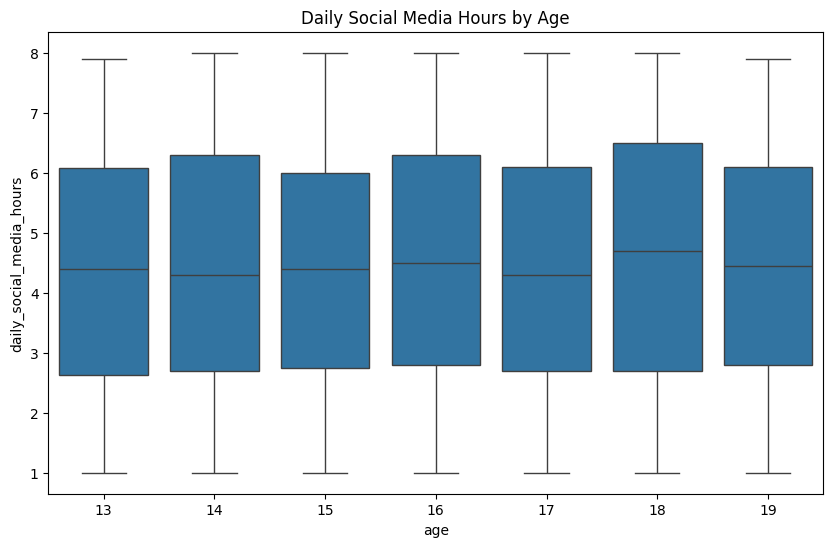

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='age', y='daily_social_media_hours', data=df)
plt.title('Daily Social Media Hours by Age')
plt.savefig('../images/daily_social_media_hours_by_age.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

In [16]:
df['depression_risk']=df['depression_risk'].map({'low':0 , 'medium':1 , 'high':2})
df['social_interaction_level']=df['social_interaction_level'].map({'low':0, 'medium':1, 'high':2})

In [17]:
nominal_cols = ['gender', 'platform_usage']

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'), nominal_cols)
], remainder='passthrough')

ct.set_output(transform="pandas")

df = ct.fit_transform(df)

In [18]:
# Model Building
X = df.drop('remainder__depression_risk', axis=1)
y = df['remainder__depression_risk']

In [19]:
X_train , X_test , y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42 )

In [20]:
model =LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy=accuracy_score(y_test,y_pred)

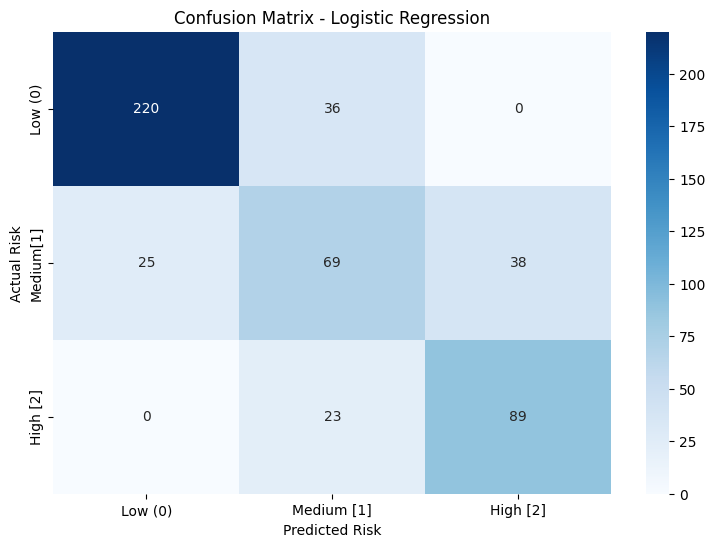

In [23]:
cm=confusion_matrix(y_test , y_pred)
plt.figure(figsize=(9,6))
sns.heatmap(cm, annot=True , fmt='d', cmap='Blues', xticklabels=['Low (0)', 'Medium [1]', 'High [2]'], yticklabels=['Low (0)', 'Medium[1]', 'High [2]'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.savefig('../images/confusion_matrix_logistic_regression.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

In [24]:
print('Results for Logistic Regression')
print(f'Accuracy {accuracy*100}%')
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Results for Logistic Regression
Accuracy 75.6%
              precision    recall  f1-score   support

         Low       0.90      0.86      0.88       256
      Medium       0.54      0.52      0.53       132
        High       0.70      0.79      0.74       112

    accuracy                           0.76       500
   macro avg       0.71      0.73      0.72       500
weighted avg       0.76      0.76      0.76       500



In [25]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [26]:
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print('Results for Decision Tree Classifier')
print(f'accuracy {dt_accuracy*100}%')
print(classification_report(y_test, dt_predictions, target_names=['Low', 'Medium', 'High']))

Results for Decision Tree Classifier
accuracy 72.8%
              precision    recall  f1-score   support

         Low       0.86      0.87      0.86       256
      Medium       0.48      0.47      0.48       132
        High       0.71      0.71      0.71       112

    accuracy                           0.73       500
   macro avg       0.68      0.68      0.68       500
weighted avg       0.73      0.73      0.73       500



In [27]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
rf_predictions=rf_model.predict(X_test)
rf_accuracy=accuracy_score(y_test, rf_predictions)
print('Results for Random Forest Classifier')
print(f'Accuracy {rf_accuracy*100}%')
print(classification_report(y_test, rf_predictions, target_names=['Low', 'Medium', 'High']))

Results for Random Forest Classifier
Accuracy 76.2%
              precision    recall  f1-score   support

         Low       0.89      0.85      0.87       256
      Medium       0.57      0.45      0.50       132
        High       0.69      0.92      0.79       112

    accuracy                           0.76       500
   macro avg       0.72      0.74      0.72       500
weighted avg       0.76      0.76      0.76       500



Random Forest Classifier is the best one here

Fine Tuning RandomForestClassifier

In [44]:
param_grid={
    'n_estimators':[50,100,200],
    'max_depth':[None, 10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf_base=RandomForestClassifier(class_weight='balanced' ,random_state=42)

In [45]:
grid_search=GridSearchCV(estimator=rf_base,param_grid=param_grid,cv=3, n_jobs=-1,scoring='f1_macro')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro')

Results for tuned Random Forest
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Tuned accuracy: 78.4
              precision    recall  f1-score   support

         Low       0.98      0.81      0.89       256
      Medium       0.59      0.58      0.59       132
        High       0.68      0.96      0.80       112

    accuracy                           0.78       500
   macro avg       0.75      0.79      0.76       500
weighted avg       0.81      0.78      0.79       500



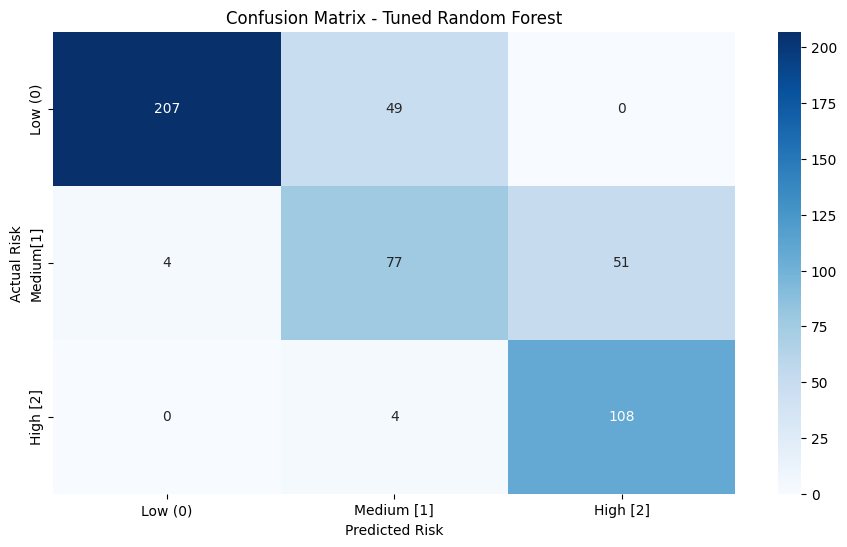

In [46]:
best_rf_model= grid_search.best_estimator_
best_rf_predictions=best_rf_model.predict(X_test)
print("Results for tuned Random Forest")
print(f'Best parameters: {grid_search.best_params_}')
print(f'Tuned accuracy: {accuracy_score(y_test,best_rf_predictions)*100}')
print(classification_report(y_test,best_rf_predictions, target_names=['Low', 'Medium', 'High']))
cm = confusion_matrix(y_test, best_rf_predictions)
plt.figure(figsize=(11,6))
sns.heatmap(cm, annot=True , fmt='d', cmap='Blues', xticklabels=['Low (0)', 'Medium [1]', 'High [2]'], yticklabels=['Low (0)', 'Medium[1]', 'High [2]'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.savefig('../images/confusion_matrix_tuned_random_forest.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

In [32]:
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df=feature_importance_df.sort_values(by='Importance',ascending=False)

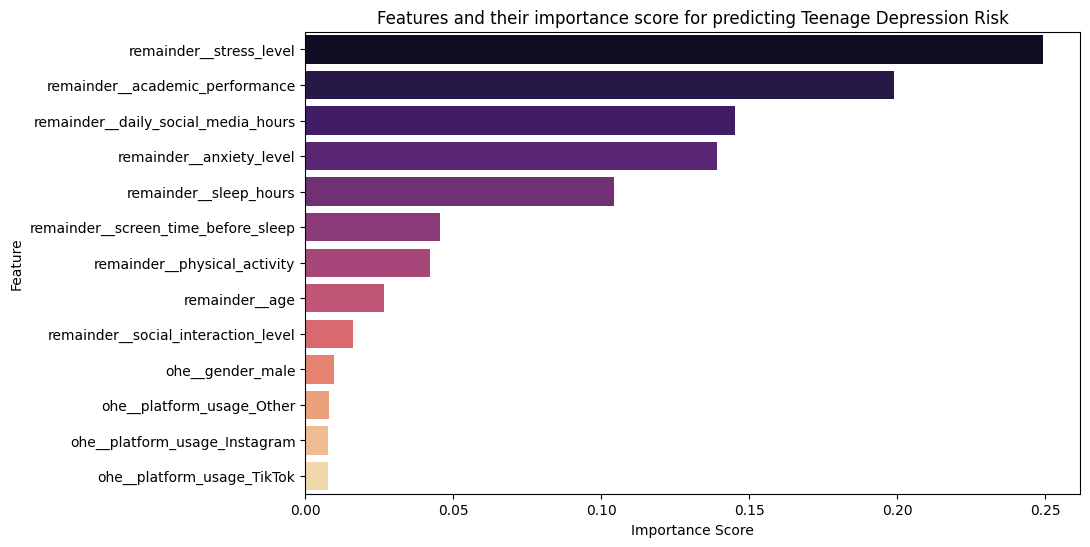

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Features and their importance score for predicting Teenage Depression Risk')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig('../images/feature_importance_random_forest.png',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

In [34]:
# saving regression model, decision tree model and random forest model
joblib.dump(model, '../models/logistic_regression_model.joblib', compress=3)
joblib.dump(dt_model, '../models/decision_tree_model.joblib', compress=3)
joblib.dump(best_rf_model, '../models/tuned_rf_model.joblib', compress=3)


['../models/tuned_rf_model.joblib']

In [35]:
# Save the ColumnTransformer object
joblib.dump(ct, '../models/column_transformer.joblib', compress=3)

['../models/column_transformer.joblib']